**DeepONet & Physics-Informed Enriched DeepONet for Eikonal Equation**

Check out the original paper for more information about each example

En-DeepONet: An enrichment approach for enhancing the expressivity of neural operators with applications to seismology

https://www.sciencedirect.com/science/article/abs/pii/S0045782523008046



# Data-Driven DeepONet

domain: [-1,1]x[-1,1]

input sensors: 24 sensors on the circle with the radius of R=[0.4,0.6]

Eikonal Equation:
$$
|∇T(x,y)| = \frac{1}{v(x,y)} \quad \text{simplified for} \quad v(x,y)=1, \quad \text{to} \quad T(x,y) = {(x^2+y^2)^{0.5}}, \quad D(x,y) = {(x^2+y^2)^{0.5}} - R
$$
where D is the distance field.

Branch inputs: list of circle-node coordinates,
Trunk inputs: a query point in the domain,
Network output: T(x,y),
Plot function:D(x,y)

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
n_sample = 30000
n_sensor = 24
radius = torch.tensor([0.3,0.6,0.9])

In [ ]:
def sample_generator(n_sample=n_sample,  radius=radius, n_sensor=n_sensor):
  branch_input = torch.zeros((n_sample, 2*n_sensor))
  trunk_input = torch.zeros((n_sample, 2))
  targets = torch.zeros((n_sample, 1))
  theta_sensors = torch.arange(0.0,24.0, 1.0)*2*torch.pi/24
  n_sample_r = n_sample // len(radius)
  for i, r in enumerate(radius):
    xs = r*torch.cos(theta_sensors)
    ys = r*torch.sin(theta_sensors)
    xys = torch.column_stack([xs, ys])
    branch_input[i*n_sample_r: (i+1)*(n_sample_r),:] = xys.flatten()
    random_points = torch.rand((n_sample_r,2))*2 - 1
    trunk_input[i*n_sample_r: (i+1)*(n_sample_r),:] = random_points
    targets[i*n_sample_r: (i+1)*(n_sample_r),:] = (torch.sqrt(random_points[:,0]**2 + random_points[:,1]**2) - r).unsqueeze(dim=1)

  return branch_input, trunk_input, targets

In [ ]:
branch_inputs, trunk_inputs, targets = sample_generator()

In [ ]:
class BranchNet(nn.Module):
  def __init__(self,n_sensor=n_sensor):
    super().__init__()
    self.Network = nn.Sequential(
        nn.Linear(2*n_sensor, 50),
        nn.Tanh(),
        nn.Linear(50, 10),
        nn.Tanh(),
        # nn.Linear(50, 10),
        # nn.Tanh(),
        # nn.Linear(50, 50),
        # nn.Tanh(),
    )

  def forward(self, x):
    return self.Network(x)

class TrunkNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.Network = nn.Sequential(
        nn.Linear(2, 50),
        nn.Tanh(),
        nn.Linear(50, 10),
        nn.Tanh(),
        # nn.Linear(50, 50),
        # nn.Tanh(),
        # nn.Linear(50, 50),
        # nn.Tanh(),
    )

  def forward(self, x):
    return self.Network(x)

In [ ]:
Branch_Model = BranchNet(n_sensor=n_sensor)
Trunk_Model = TrunkNet()

In [ ]:
optim = torch.optim.Adam(list(Trunk_Model.parameters())+list(Branch_Model.parameters()), lr=5e-4)
n_epochs = 2000

In [ ]:
for epoch in range(n_epochs):
  optim.zero_grad()
  Bs = Branch_Model(branch_inputs)
  Ts = Trunk_Model(trunk_inputs)
  T_hat = torch.linalg.vecdot(Ts,Bs)
  Loss = torch.mean((targets.squeeze() - T_hat)**2)
  Loss.backward()
  optim.step()
  if epoch%50 == 49:
    print(f"Epoch: {epoch+1}/{n_epochs}, Loss: {Loss.item():.5f}")


Epoch: 50/2000, Loss: 0.07811
Epoch: 100/2000, Loss: 0.04604
Epoch: 150/2000, Loss: 0.01247
Epoch: 200/2000, Loss: 0.00569
Epoch: 250/2000, Loss: 0.00388
Epoch: 300/2000, Loss: 0.00268
Epoch: 350/2000, Loss: 0.00201
Epoch: 400/2000, Loss: 0.00166
Epoch: 450/2000, Loss: 0.00142
Epoch: 500/2000, Loss: 0.00126
Epoch: 550/2000, Loss: 0.00116
Epoch: 600/2000, Loss: 0.00104
Epoch: 650/2000, Loss: 0.00096
Epoch: 700/2000, Loss: 0.00091
Epoch: 750/2000, Loss: 0.00085
Epoch: 800/2000, Loss: 0.00080
Epoch: 850/2000, Loss: 0.00077
Epoch: 900/2000, Loss: 0.00073
Epoch: 950/2000, Loss: 0.00070
Epoch: 1000/2000, Loss: 0.00067
Epoch: 1050/2000, Loss: 0.00064
Epoch: 1100/2000, Loss: 0.00062
Epoch: 1150/2000, Loss: 0.00067
Epoch: 1200/2000, Loss: 0.00057
Epoch: 1250/2000, Loss: 0.00055
Epoch: 1300/2000, Loss: 0.00054
Epoch: 1350/2000, Loss: 0.00059
Epoch: 1400/2000, Loss: 0.00050
Epoch: 1450/2000, Loss: 0.00049
Epoch: 1500/2000, Loss: 0.00048
Epoch: 1550/2000, Loss: 0.00046
Epoch: 1600/2000, Loss: 0.00

In [ ]:
## ==== Model Evaluation ==== ##
r_eval = 0.45
nx, ny = 100, 100
x_min, x_max, y_min, y_max = -1,1,-1,1
x = torch.linspace(x_min, x_max, nx)
y = torch.linspace(y_min, y_max, ny)

Y,X = torch.meshgrid(y,x, indexing='ij')
trunk_inputs_eval = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)


theta_sensors = torch.arange(0.0,24.0, 1.0)*2*torch.pi/24

xs = r_eval*torch.cos(theta_sensors)
ys = r_eval*torch.sin(theta_sensors)
xys = torch.column_stack([xs, ys])

branch_inputs_eval = xys.flatten()
with torch.no_grad():
  Bs_eval = Branch_Model(branch_inputs_eval)
  Ts_eval = Trunk_Model(trunk_inputs_eval)
  pred = torch.linalg.vecdot(Ts_eval, Bs_eval)
  exact = (torch.sqrt(trunk_inputs_eval[:,0]**2 + trunk_inputs_eval[:,1]**2) - r_eval)


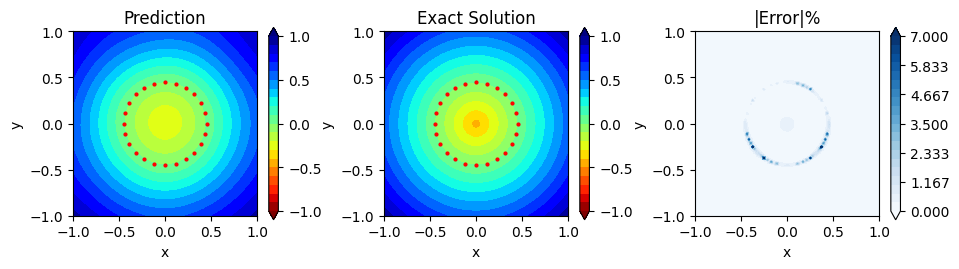

In [ ]:
# ==== plot the solution === #
coords = trunk_inputs_eval.detach().cpu()

x_plot = coords[:, 0].numpy()
y_plot = coords[:, 1].numpy()

pred_plot  = pred.detach().cpu().numpy().squeeze()
exact_plot = exact.detach().cpu().numpy().squeeze()
error_plot = abs((pred_plot - exact_plot)/exact_plot)   # or np.abs(pred_plot - exact_plot)

# Define fixed contour levels
levels_main  = np.linspace(-1, 1, 21)
levels_error = np.linspace(0, 7, 21)

fig, ax = plt.subplots(1, 3, figsize=(11, 2.5))

im0 = ax[0].tricontourf(
    x_plot, y_plot, pred_plot,
    levels=levels_main,
    cmap="jet_r",
    extend="both"
)

im1 = ax[1].tricontourf(
    x_plot, y_plot, exact_plot,
    levels=levels_main,
    cmap="jet_r",
    extend="both"
)

im2 = ax[2].tricontourf(
    x_plot, y_plot, error_plot,
    levels=levels_error,
    cmap="Blues",
    extend="both"
)

cbar0 = fig.colorbar(im0, ax=ax[0], ticks=np.linspace(-1, 1, 5))
cbar1 = fig.colorbar(im1, ax=ax[1], ticks=np.linspace(-1, 1, 5))
cbar2 = fig.colorbar(im2, ax=ax[2], ticks=np.linspace(0, 7, 7))

ax[0].set_title("Prediction")
ax[1].set_title("Exact Solution")
ax[2].set_title("|Error|%")
ax[0].plot(xs, ys, color='red', marker="o", markersize=2, ls='')
ax[1].plot(xs, ys, color='red', marker="o", markersize=2, ls='')
for a in ax:
    a.set_xlabel("x")
    a.set_ylabel("y")
    a.set_aspect("equal")
    a.set_xlim(x_min, x_max)
    a.set_ylim(y_min, y_max)

plt.subplots_adjust(wspace=0.35)
plt.show()

# Physics-Informed Version of DeepONet

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import math
import matplotlib.pyplot as plt
import time

In [ ]:
n_sample = 30000
n_sensor = 24
radius = torch.tensor([0.3,0.6,0.9])

In [ ]:
def sample_generator(n_sample=n_sample,  radius=radius, n_sensor=n_sensor):
  n_sample_ = n_sample //2
  branch_input_dom = torch.zeros((n_sample_, 2*n_sensor))
  trunk_input_dom = torch.zeros((n_sample_, 2))
  branch_input_BC = torch.zeros((n_sample_, 2*n_sensor))
  trunk_input_BC = torch.zeros((n_sample_, 2))

  theta_sensors = torch.arange(0.0,24.0, 1.0)*2*torch.pi/24
  n_sample_r = n_sample_ // len(radius)
  for i, r in enumerate(radius):
    xs = r*torch.cos(theta_sensors)
    ys = r*torch.sin(theta_sensors)
    xys = torch.column_stack([xs, ys])

    branch_input_dom[i*n_sample_r: (i+1)*(n_sample_r),:] = xys.flatten()
    branch_input_BC[i*n_sample_r: (i+1)*(n_sample_r),:] = xys.flatten()

    random_points = torch.rand((n_sample_r,2))*2 - 1
    trunk_input_dom[i*n_sample_r: (i+1)*(n_sample_r),:] = random_points

    trunk_input_BC[i*n_sample_r: (i+1)*(n_sample_r),:] = xys.repeat(math.ceil(n_sample_r / xys.shape[0]), 1)[:n_sample_r, :]

  return branch_input_dom, trunk_input_dom, branch_input_BC, trunk_input_BC #, targets

In [ ]:
class BranchNet(nn.Module):
  def __init__(self,n_sensor=n_sensor):
    super().__init__()
    self.Network = nn.Sequential(
        nn.Linear(2*n_sensor, 50),
        nn.Tanh(),
        nn.Linear(50, 50),
        nn.Tanh(),
        nn.Linear(50, 10),
        # nn.Tanh(),
        # nn.Linear(50, 10),
        # nn.Tanh(),
    )

  def forward(self, x):
    return self.Network(x)

class TrunkNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.Network = nn.Sequential(
        nn.Linear(2, 50),
        nn.Tanh(),
        nn.Linear(50, 50),
        nn.Tanh(),
        nn.Linear(50, 10),
        # nn.Tanh(),
        # nn.Linear(50, 10),
        # nn.Tanh(),
    )

  def forward(self, x):
    return self.Network(x)

In [ ]:
Branch_Model = BranchNet(n_sensor=n_sensor)
Trunk_Model = TrunkNet()

In [ ]:
n_epochs = 1500
initial_lr = 1e-3
final_lr = 0.5e-4
gamma = (final_lr/initial_lr)**(1/n_epochs)
optim = torch.optim.Adam(list(Trunk_Model.parameters())+list(Branch_Model.parameters()), lr=initial_lr)
Scheduler = torch.optim.lr_scheduler.ExponentialLR(optim, gamma=gamma)

In [ ]:
# --- batch --- #
batch_size = 500

start_time = time.time()
Loss_Hist = []
for epoch in range(n_epochs):
  branch_input_dom, trunk_input_dom, branch_input_BC, trunk_input_BC = sample_generator()
  n_batches = len(trunk_input_dom) // batch_size
  indices = torch.randperm(trunk_input_dom.shape[0]) #random index of inputs
  for b in range(n_batches):
    optim.zero_grad()
    idx = indices[b*batch_size:(b+1)*batch_size]
    branch_input_dom_batch = branch_input_dom[idx]
    trunk_input_dom_batch = trunk_input_dom[idx].clone().detach().requires_grad_(True)
    branch_input_BC_batch = branch_input_BC[idx]
    trunk_input_BC_batch = trunk_input_BC[idx]

    Bs_dom = Branch_Model(branch_input_dom_batch)
    Ts_dom = Trunk_Model(trunk_input_dom_batch)
    T_dom = torch.linalg.vecdot(Ts_dom,Bs_dom)
    dT = torch.autograd.grad(outputs=T_dom, inputs=trunk_input_dom_batch, grad_outputs=torch.ones_like(T_dom), create_graph=True, retain_graph=True)[0]
    dT_dx = dT[:,0]
    dT_dy = dT[:,1]
    Loss_PDE = torch.mean(((dT_dx)**2 + (dT_dy)**2 - 1.0 )**2)

    rr = trunk_input_dom_batch[:,0]**2+trunk_input_dom_batch[:,1]**2 # distance from the origin
    RR = branch_input_dom_batch[:,0]**2+branch_input_dom_batch[:,1]**2 # circle with zero radius
    Loss_sign = torch.mean(((1-torch.sign(T_dom))*torch.abs(T_dom)*(1+torch.sign(rr-RR)))) # positivity imposition

    Bs_BC = Branch_Model(branch_input_BC_batch)
    Ts_BC = Trunk_Model(trunk_input_BC_batch)
    T_BC = torch.linalg.vecdot(Ts_BC, Bs_BC)
    Loss_BC = torch.mean((T_BC)**2)


    Losses_Eikonal = torch.stack([Loss_PDE, Loss_BC, Loss_sign])

    optim.zero_grad()

    Loss = Losses_Eikonal.sum()
    Loss_epoch = Loss.item()

    Loss.backward()

    optim.step()

  Scheduler.step()
  Loss_Hist.append(Loss_epoch)
  if epoch%50 == 49:
    print(f"Epoch: {epoch+1}/{n_epochs}, Loss Total: {Loss_epoch:.5f},   "
    f"Eikonal Loss: {', '.join(f'{l.item():.4f}' for l in Losses_Eikonal)},  "
    f"Run Time: {time.time()-start_time:.0f}s")
  elif epoch==0:
    print(f"Epoch: {epoch+1}/{n_epochs}, Loss Total: {Loss_epoch:.5f},   "
    f"Eikonal Loss: {', '.join(f'{l.item():.4f}' for l in Losses_Eikonal)},  "
    f"Run Time: {time.time()-start_time:.0f}s")


Epoch: 1/1500, Loss Total: 0.70213,   Eikonal Loss: 0.3121, 0.3100, 0.0801,  Run Time: 0s
Epoch: 50/1500, Loss Total: 0.02212,   Eikonal Loss: 0.0207, 0.0006, 0.0009,  Run Time: 12s
Epoch: 100/1500, Loss Total: 0.01335,   Eikonal Loss: 0.0103, 0.0009, 0.0022,  Run Time: 26s
Epoch: 150/1500, Loss Total: 0.00886,   Eikonal Loss: 0.0081, 0.0007, 0.0000,  Run Time: 40s
Epoch: 200/1500, Loss Total: 0.00460,   Eikonal Loss: 0.0044, 0.0002, 0.0000,  Run Time: 53s
Epoch: 250/1500, Loss Total: 0.00376,   Eikonal Loss: 0.0032, 0.0005, 0.0000,  Run Time: 66s
Epoch: 300/1500, Loss Total: 0.00476,   Eikonal Loss: 0.0041, 0.0001, 0.0005,  Run Time: 79s
Epoch: 350/1500, Loss Total: 0.00296,   Eikonal Loss: 0.0028, 0.0001, 0.0001,  Run Time: 91s
Epoch: 400/1500, Loss Total: 0.00146,   Eikonal Loss: 0.0012, 0.0001, 0.0002,  Run Time: 104s
Epoch: 450/1500, Loss Total: 0.00233,   Eikonal Loss: 0.0021, 0.0001, 0.0001,  Run Time: 117s
Epoch: 500/1500, Loss Total: 0.00217,   Eikonal Loss: 0.0020, 0.0001, 0.

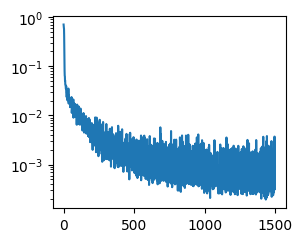

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(3,2.5))
ax.semilogy(Loss_Hist)
plt.show()

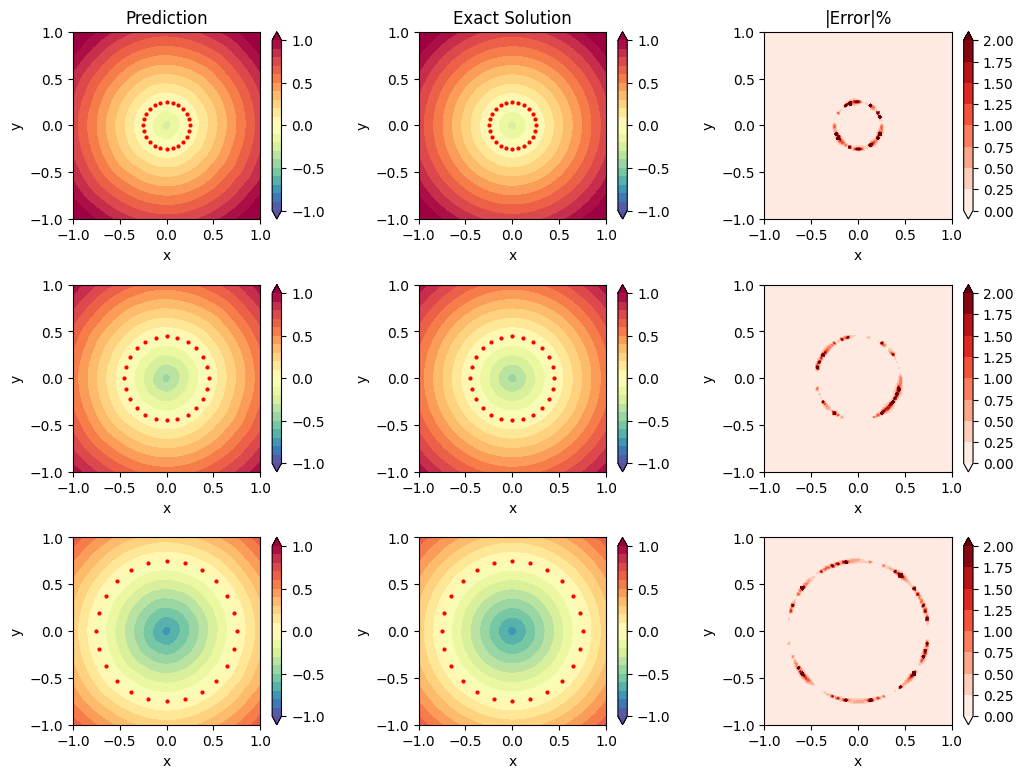

In [ ]:
## ==== Model Evaluation and 3x3 Plot ==== ##

r_eval_list = [0.25, 0.45, 0.75]   # one radius for each row

nx, ny = 100, 100
x_min, x_max, y_min, y_max = -1, 1, -1, 1

x = torch.linspace(x_min, x_max, nx)
y = torch.linspace(y_min, y_max, ny)

Y, X = torch.meshgrid(y, x, indexing="ij")
trunk_inputs_eval = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)

theta_sensors = torch.arange(0.0, 24.0, 1.0)*2*torch.pi/24

# Fixed contour levels
levels_main = np.linspace(-1, 1, 21)
levels_error = np.linspace(0, 2, 9)

fig, ax = plt.subplots(3, 3, figsize=(12, 9))

for row, r_eval in enumerate(r_eval_list):

    # Sensor points on the circle
    xs = r_eval*torch.cos(theta_sensors)
    ys = r_eval*torch.sin(theta_sensors)
    xys = torch.column_stack([xs, ys])

    branch_inputs_eval = xys.flatten()

    with torch.no_grad():
        Bs_eval = Branch_Model(branch_inputs_eval)
        Ts_eval = Trunk_Model(trunk_inputs_eval)
        pred = torch.linalg.vecdot(Ts_eval, Bs_eval)
        exact = torch.sqrt(trunk_inputs_eval[:, 0]**2 + trunk_inputs_eval[:, 1]**2) - r_eval

    # Convert for plotting
    coords = trunk_inputs_eval.detach().cpu()
    x_plot = coords[:, 0].numpy()
    y_plot = coords[:, 1].numpy()

    pred_plot = pred.detach().cpu().numpy().squeeze()
    exact_plot = exact.detach().cpu().numpy().squeeze()
    error_plot = abs((pred_plot - exact_plot)/exact_plot) #pred_plot - exact_plot

    # ---- Prediction ----
    im0 = ax[row, 0].tricontourf(
        x_plot, y_plot, pred_plot,
        levels=levels_main,
        cmap="Spectral_r",
        extend="both"
    )
    fig.colorbar(im0, ax=ax[row, 0], ticks=np.linspace(-1, 1, 5))

    # ---- Exact ----
    im1 = ax[row, 1].tricontourf(
        x_plot, y_plot, exact_plot,
        levels=levels_main,
        cmap="Spectral_r",
        extend="both"
    )
    fig.colorbar(im1, ax=ax[row, 1], ticks=np.linspace(-1, 1, 5))

    # ---- Error ----
    im2 = ax[row, 2].tricontourf(
        x_plot, y_plot, error_plot,
        levels=levels_error,
        cmap="Reds",
        extend="both"
    )
    fig.colorbar(im2, ax=ax[row, 2], ticks=np.linspace(0, 2, 9))

    # Plot sensor points on prediction and exact solution
    ax[row, 0].plot(xs.detach().cpu().numpy(), ys.detach().cpu().numpy(), color='red', marker="o", markersize=2, ls='')
    ax[row, 1].plot(xs.detach().cpu().numpy(), ys.detach().cpu().numpy(), color='red', marker="o", markersize=2, ls='')

    # Row labels
    ax[row, 0].set_ylabel(f"y\nr={r_eval}")

# Column titles
ax[0, 0].set_title("Prediction")
ax[0, 1].set_title("Exact Solution")
ax[0, 2].set_title("|Error|%")

# Axis formatting
for a in ax.flat:
    a.set_xlabel("x")
    a.set_ylabel("y")
    a.set_aspect("equal")
    a.set_xlim(x_min, x_max)
    a.set_ylim(y_min, y_max)

plt.subplots_adjust(wspace=0.45, hspace=0.35)
plt.show()

# Physics-Informed Enriched DeepONet

In [1]:
import torch
import torch.nn as nn
import numpy as np
import math
import matplotlib.pyplot as plt
import time

In [58]:
n_sample = 20000
n_sensor = 24
radius = 0.3

In [59]:
def sample_generator(n_sample=n_sample,  radius=radius, n_sensor=n_sensor):

  n_sample_ = n_sample //2
  branch_input_dom = torch.zeros((n_sample_, 2*n_sensor))
  trunk_input_dom = torch.zeros((n_sample_, 2))
  branch_input_BC = torch.zeros((n_sample_, 2*n_sensor))
  trunk_input_BC = torch.zeros((n_sample_, 2))

  theta_sensors = torch.arange(0.0,n_sensor, 1.0)*2*torch.pi/n_sensor
  n_source = 100
  n_sample_source = n_sample_ //n_source

  for i in range(n_source):
    xys_source = torch.rand(2)-0.5 #torch.rand(2)*0.5-0.25   #
    xs = radius*torch.cos(theta_sensors) + xys_source[0]
    ys = radius*torch.sin(theta_sensors) + xys_source[1]
    xys = torch.column_stack([xs, ys])

    branch_input_dom[i*n_sample_source: (i+1)*n_sample_source,:] = xys.flatten()
    branch_input_BC[i*n_sample_source: (i+1)*n_sample_source,:] = xys.flatten()

    random_points = torch.rand((n_sample_source,2))*2 - 1
    trunk_input_dom[i*n_sample_source: (i+1)*n_sample_source,:] = random_points
    idx = torch.randint(len(xs),(n_sample_source,))#[0]
    trunk_input_BC[i*n_sample_source: (i+1)*n_sample_source,:] = torch.column_stack([xs[idx], ys[idx]]) # select one of the xy combo

  return branch_input_dom, trunk_input_dom, branch_input_BC, trunk_input_BC #, targets

In [60]:
branch_input_dom, trunk_input_dom, branch_input_BC, trunk_input_BC = sample_generator()

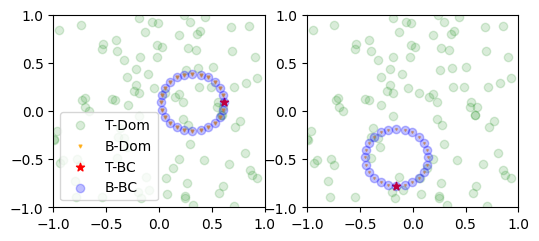

In [61]:
fig, ax = plt.subplots(1,2, figsize=(6,2.5))
even = np.arange(0,48,2) #np.array([0,2,4,6,8,10,12,14])
odds = np.arange(1,48,2)#np.array([1,3,5,7,9,11,13,15])

ax[0].scatter(trunk_input_dom[:100,0], trunk_input_dom[:100,1], color='green', marker='o', alpha=0.15, label="T-Dom")
ax[0].scatter(branch_input_dom[0,even], branch_input_dom[0,odds], color='orange', marker='v', alpha=0.75,s=4, label="B-Dom")
ax[0].scatter(trunk_input_BC[0,0], trunk_input_BC[0,1], color='red', label="T-BC", marker='*')
ax[0].scatter(branch_input_BC[0,even], branch_input_BC[0,odds], color='blue', label="B-BC", marker='o', alpha=0.25)

ax[1].scatter(trunk_input_dom[:100,0], trunk_input_dom[:100,1], color='green', marker='o', alpha=0.15)
ax[1].scatter(branch_input_dom[150,even], branch_input_dom[150,odds], color='orange', marker='v', alpha=0.75, s=1)
ax[1].scatter(trunk_input_BC[150,0], trunk_input_BC[150,1], color='red', label="T-BC", marker='*')
ax[1].scatter(branch_input_BC[150,even], branch_input_BC[150,odds], color='blue', label="B-BC", marker='o', alpha=0.25)


ax[0].set_xlim(-1,1), ax[0].set_ylim(-1,1)
ax[1].set_xlim(-1,1), ax[1].set_ylim(-1,1)
ax[0].legend()#, ax[1].legend()
plt.show()

In [62]:
class BranchNet(nn.Module):
  def __init__(self,n_sensor=n_sensor):
    super().__init__()
    self.Network = nn.Sequential(
        nn.Linear(2*n_sensor, 50),
        nn.Tanh(),
        nn.Linear(50, 50),
        nn.Tanh(),
        nn.Linear(50, 50),
        # nn.Tanh(),
        # nn.Linear(50, 50),
        # nn.Tanh(),
    )

  def forward(self, x):
    return self.Network(x)

class TrunkNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.Network = nn.Sequential(
        nn.Linear(2, 50),
        nn.Tanh(),
        nn.Linear(50, 50),
        nn.Tanh(),
        nn.Linear(50, 50),
        # nn.Tanh(),
        # nn.Linear(50, 50),
        # nn.Tanh(),
    )

  def forward(self, x):
    return self.Network(x)

class RootNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.Network = nn.Sequential(
        nn.Linear(150,50),
        nn.Tanh(),
        nn.Linear(50,20),
        nn.Tanh(),
        nn.Linear(20,1)
    )
  def forward(self, dot, plus, minus):
    inputs = torch.cat([dot, plus, minus], dim=1)
    return self.Network(inputs)

In [63]:
Branch_Model = BranchNet(n_sensor=n_sensor)
Trunk_Model = TrunkNet()
Root_Model = RootNet()

In [64]:
n_epochs = 750
initial_lr = 1e-3
final_lr = 1e-4
gamma = (final_lr/initial_lr)**(1/n_epochs)
optim = torch.optim.Adam(list(Trunk_Model.parameters())+list(Branch_Model.parameters())+list(Root_Model.parameters()), lr=initial_lr)
Scheduler = torch.optim.lr_scheduler.ExponentialLR(optim, gamma=gamma)

In [65]:
# --- batch --- #
batch_size = 500

start_time = time.time()
Loss_Hist = []
for epoch in range(n_epochs):
  branch_input_dom, trunk_input_dom, branch_input_BC, trunk_input_BC = sample_generator()
  n_batches = len(trunk_input_dom) // batch_size
  indices = torch.randperm(trunk_input_dom.shape[0]) #random index of inputs
  for b in range(n_batches):
    optim.zero_grad()
    idx = indices[b*batch_size:(b+1)*batch_size]
    branch_input_dom_batch = branch_input_dom[idx]
    trunk_input_dom_batch = trunk_input_dom[idx].clone().detach().requires_grad_(True)
    branch_input_BC_batch = branch_input_BC[idx]
    trunk_input_BC_batch = trunk_input_BC[idx]

    Bs_dom = Branch_Model(branch_input_dom_batch)
    Ts_dom = Trunk_Model(trunk_input_dom_batch)

    T_dom_dot = Ts_dom * Bs_dom
    T_dom_plus = Ts_dom + Bs_dom
    T_dom_minus = Ts_dom - Bs_dom
    T_dom = Root_Model(T_dom_dot, T_dom_plus, T_dom_minus)

    dT = torch.autograd.grad(outputs=T_dom, inputs=trunk_input_dom_batch, grad_outputs=torch.ones_like(T_dom), create_graph=True, retain_graph=True)[0]
    dT_dx = dT[:,0]
    dT_dy = dT[:,1]
    Loss_PDE = torch.mean(((dT_dx)**2 + (dT_dy)**2 - 1.0 )**2)

    # positivity imposition
    evens = np.arange(0,n_sensor*2,2)
    odds = np.arange(1,n_sensor*2,2)
    source_x = torch.mean(branch_input_dom_batch[:,evens], dim=1)
    source_y = torch.mean(branch_input_dom_batch[:,odds], dim=1)
    RR = radius # real radius
    rr = torch.sqrt((trunk_input_dom_batch[:,0:1] - source_x[:, None])**2 + (trunk_input_dom_batch[:,1:2] - source_y[:, None])**2) # distance from the source
    Loss_sign = torch.mean(((1-torch.sign(T_dom))*torch.abs(T_dom)*(1+torch.sign(rr-RR)))) # positivity imposition

    Bs_BC = Branch_Model(branch_input_BC_batch)
    Ts_BC = Trunk_Model(trunk_input_BC_batch)

    T_BC_dot = Ts_BC * Bs_BC
    T_BC_plus = Ts_BC + Bs_BC
    T_BC_minus = Ts_BC - Bs_BC

    T_BC = Root_Model(T_BC_dot, T_BC_plus, T_BC_minus)
    Loss_BC = torch.mean((T_BC)**2)


    Losses_Eikonal = torch.stack([Loss_PDE, Loss_BC, Loss_sign])

    optim.zero_grad()

    Loss = Losses_Eikonal.sum()
    Loss_epoch = Loss.item()

    Loss.backward()

    optim.step()

  Scheduler.step()
  Loss_Hist.append(Loss_epoch)
  if epoch%50 == 49:
    print(f"Epoch: {epoch+1}/{n_epochs}, Loss Total: {Loss_epoch:.5f},   "
    f"Eikonal Loss: {', '.join(f'{l.item():.4f}' for l in Losses_Eikonal)},  "
    f"Run Time: {time.time()-start_time:.0f}s")
  elif epoch==0:
    print(f"Epoch: {epoch+1}/{n_epochs}, Loss Total: {Loss_epoch:.5f},   "
    f"Eikonal Loss: {', '.join(f'{l.item():.4f}' for l in Losses_Eikonal)},  "
    f"Run Time: {time.time()-start_time:.0f}s")


Epoch: 1/750, Loss Total: 1.00335,   Eikonal Loss: 0.9997, 0.0036, 0.0000,  Run Time: 0s
Epoch: 50/750, Loss Total: 0.00988,   Eikonal Loss: 0.0066, 0.0013, 0.0020,  Run Time: 16s
Epoch: 100/750, Loss Total: 0.00193,   Eikonal Loss: 0.0015, 0.0004, 0.0000,  Run Time: 33s
Epoch: 150/750, Loss Total: 0.00171,   Eikonal Loss: 0.0012, 0.0004, 0.0001,  Run Time: 48s
Epoch: 200/750, Loss Total: 0.00175,   Eikonal Loss: 0.0010, 0.0007, 0.0000,  Run Time: 63s
Epoch: 250/750, Loss Total: 0.00172,   Eikonal Loss: 0.0015, 0.0002, 0.0000,  Run Time: 77s
Epoch: 300/750, Loss Total: 0.00097,   Eikonal Loss: 0.0008, 0.0001, 0.0000,  Run Time: 99s
Epoch: 350/750, Loss Total: 0.00121,   Eikonal Loss: 0.0007, 0.0005, 0.0000,  Run Time: 116s
Epoch: 400/750, Loss Total: 0.00094,   Eikonal Loss: 0.0007, 0.0002, 0.0000,  Run Time: 129s
Epoch: 450/750, Loss Total: 0.00076,   Eikonal Loss: 0.0006, 0.0002, 0.0000,  Run Time: 144s
Epoch: 500/750, Loss Total: 0.00051,   Eikonal Loss: 0.0002, 0.0001, 0.0002,  Run

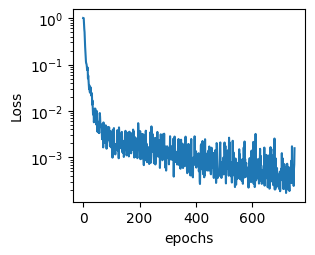

In [66]:
fig, ax = plt.subplots(1,1, figsize=(3,2.5))
ax.semilogy(Loss_Hist)
ax.set_xlabel("epochs")
ax.set_ylabel("Loss")
plt.show()

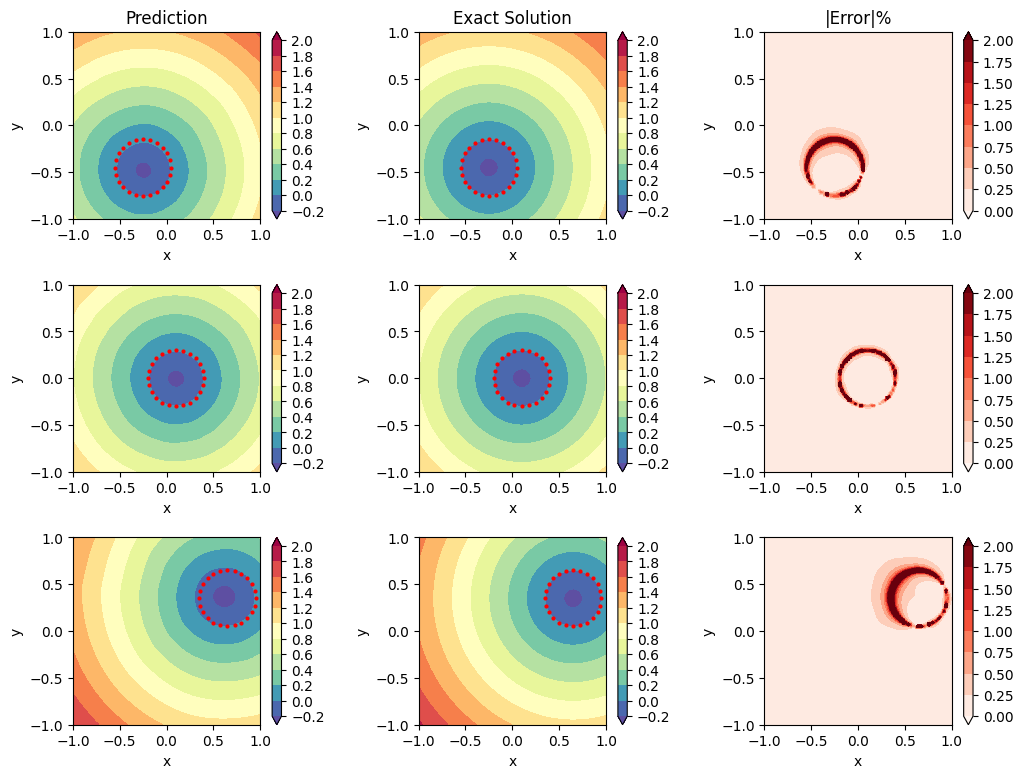

In [67]:
## ==== Model Evaluation and 3x3 Plot ==== ##

x_sources = [-0.25, 0.1, 0.65]
y_sources = [-0.45, 0.0, 0.35]

nx, ny = 100, 100
x_min, x_max, y_min, y_max = -1, 1, -1, 1

x = torch.linspace(x_min, x_max, nx)
y = torch.linspace(y_min, y_max, ny)

Y, X = torch.meshgrid(y, x, indexing="ij")
trunk_inputs_eval = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)

theta_sensors = torch.arange(0.0, 24.0, 1.0)*2*torch.pi/24

# Fixed contour levels
levels_main = np.linspace(-0.2, 2, 12)
levels_error = np.linspace(0, 2, 9)

fig, ax = plt.subplots(3, 3, figsize=(12, 9))

for row, (x_source, y_source) in enumerate(zip(x_sources, y_sources)):

    # Sensor points on the circle
    xs = radius*torch.cos(theta_sensors) + x_source
    ys = radius*torch.sin(theta_sensors) + y_source
    xys = torch.column_stack([xs, ys])

    branch_inputs_eval = xys.flatten()

    with torch.no_grad():
        Bs_eval = Branch_Model(branch_inputs_eval)
        Ts_eval = Trunk_Model(trunk_inputs_eval)
        pred_dot = Ts_eval * Bs_eval
        pred_plus = Ts_eval + Bs_eval
        pred_minus = Ts_eval - Bs_eval
        pred = Root_Model(pred_dot, pred_plus, pred_minus)
        distance = torch.sqrt((trunk_inputs_eval[:, 0] - x_source)**2 + (trunk_inputs_eval[:, 1] - y_source)**2)
        exact = distance - radius

    # Convert for plotting
    coords = trunk_inputs_eval.detach().cpu()
    x_plot = coords[:, 0].numpy()
    y_plot = coords[:, 1].numpy()

    pred_plot = pred.detach().cpu().numpy().squeeze()
    exact_plot = exact.detach().cpu().numpy().squeeze()
    error_plot = abs((pred_plot - exact_plot)/exact_plot)

    # ---- Prediction ----
    im0 = ax[row, 0].tricontourf(
        x_plot, y_plot, pred_plot,
        levels=levels_main,
        cmap="Spectral_r",
        extend="both"
    )
    fig.colorbar(im0, ax=ax[row, 0], ticks=np.linspace(-0.2, 2, 12))

    # ---- Exact ----
    im1 = ax[row, 1].tricontourf(
        x_plot, y_plot, exact_plot,
        levels=levels_main,
        cmap="Spectral_r",
        extend="both"
    )
    fig.colorbar(im1, ax=ax[row, 1], ticks=np.linspace(-0.2, 2, 12))

    # ---- Error ----
    im2 = ax[row, 2].tricontourf(
        x_plot, y_plot, error_plot,
        levels=levels_error,
        cmap="Reds",
        extend="both"
    )
    fig.colorbar(im2, ax=ax[row, 2], ticks=np.linspace(0, 2, 9))

    # Plot sensor points on prediction and exact solution
    ax[row, 0].plot(xs.detach().cpu().numpy(), ys.detach().cpu().numpy(), color='red', marker="o", markersize=2, ls='')
    ax[row, 1].plot(xs.detach().cpu().numpy(), ys.detach().cpu().numpy(), color='red', marker="o", markersize=2, ls='')

    # Row labels
    ax[row, 0].set_ylabel(f"y\nr={radius}")

# Column titles
ax[0, 0].set_title("Prediction")
ax[0, 1].set_title("Exact Solution")
ax[0, 2].set_title("|Error|%")

# Axis formatting
for a in ax.flat:
    a.set_xlabel("x")
    a.set_ylabel("y")
    a.set_aspect("equal")
    a.set_xlim(x_min, x_max)
    a.set_ylim(y_min, y_max)

plt.subplots_adjust(wspace=0.45, hspace=0.35)
plt.show()